In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

from pmdarima import auto_arima

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving master_influenza_dataset.csv to master_influenza_dataset.csv


In [ ]:
df = pd.read_csv("master_influenza_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)
df.head()

(780, 10)


,Year,Week,ILI_Total,Total_Patients,Weighted_ILI,Region,Season,Date,Population_2024,ILI_per_100k
0,2019,40,5637,333469,1.67601,Region 4,2019_20,2019-09-30,70994814.0,7.940017
1,2019,41,5349,317260,1.63170,Region 4,2019_20,2019-10-07,70994814.0,7.534353
2,2019,42,5711,311644,1.81532,Region 4,2019_20,2019-10-14,70994814.0,8.044250
3,2019,43,6683,322052,1.96609,Region 4,2019_20,2019-10-21,70994814.0,9.413364
4,2019,44,7119,318970,2.29988,Region 4,2019_20,2019-10-28,70994814.0,10.027493


In [ ]:
selected_regions = ["Region 4", "Region 6", "Region 9"]

target_col = "ILI_per_100k"

In [ ]:
def prepare_region_series(df, region_name, target_col):

    temp = df[df["Region"] == region_name].copy()

    temp = temp.sort_values("Date").reset_index(drop=True)

    series = temp[target_col].values

    dates = temp["Date"].values

    return temp, series, dates

In [ ]:
def train_test_split_ts(series, test_size=0.20):

    n = len(series)

    split = int(n * (1 - test_size))

    train = series[:split]
    test = series[split:]

    return train, test

In [ ]:
def fit_arima_region(region_name):

    temp, series, dates = prepare_region_series(
        df, region_name, target_col
    )

    train, test = train_test_split_ts(series)

    model = auto_arima(
        train,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False
    )

    forecast = model.predict(n_periods=len(test))

    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)

    order = model.order

    result = {
        "Region": region_name,
        "Order": str(order),
        "RMSE": rmse,
        "MAE": mae
    }

    pred_df = pd.DataFrame({
        "Region": region_name,
        "Index": np.arange(len(series)),
        "Actual": series,
        "Train_Test": ["Train"]*len(train) + ["Test"]*len(test),
        "Forecast": [np.nan]*len(train) + list(forecast)
    })

    return result, pred_df, model

In [ ]:
all_results = []
all_preds = []

for region in selected_regions:

    result, pred_df, model = fit_arima_region(region)

    all_results.append(result)
    all_preds.append(pred_df)

In [ ]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df.round(4)

,Region,Order,RMSE,MAE
0,Region 6,"(2, 0, 3)",7.7619,6.3559
1,Region 9,"(0, 1, 3)",18.8348,12.6810
2,Region 4,"(1, 0, 2)",19.6927,13.7933


In [ ]:
predictions_df = pd.concat(all_preds, ignore_index=True)

predictions_df.head()

,Region,Index,Actual,Train_Test,Forecast
0,Region 4,0,7.940017,Train,NaN
1,Region 4,1,7.534353,Train,NaN
2,Region 4,2,8.044250,Train,NaN
3,Region 4,3,9.413364,Train,NaN
4,Region 4,4,10.027493,Train,NaN


In [ ]:
def plot_arima(region_name):

    temp = predictions_df[
        predictions_df["Region"] == region_name
    ].copy()

    plt.figure(figsize=(14,5))

    plt.plot(
        temp["Actual"].values,
        label="Actual",
        linewidth=2
    )

    plt.plot(
        temp["Forecast"].values,
        label="ARIMA Forecast",
        linewidth=2
    )

    split_idx = temp[temp["Train_Test"] == "Test"].index.min()

    plt.axvline(
        x=split_idx - temp.index.min(),
        linestyle="--",
        alpha=0.7
    )

    plt.title(f"{region_name} | ARIMA Forecast")
    plt.xlabel("Weeks")
    plt.ylabel(target_col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

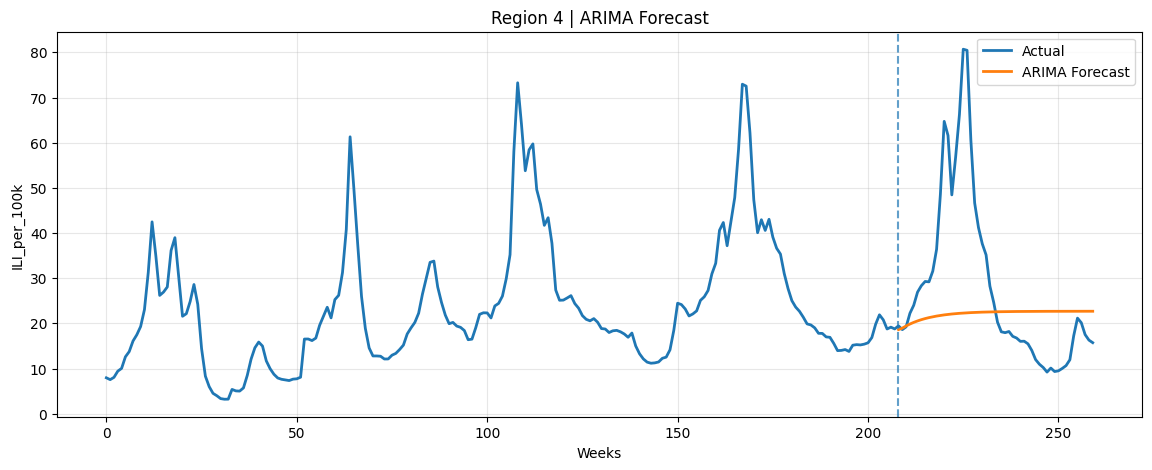

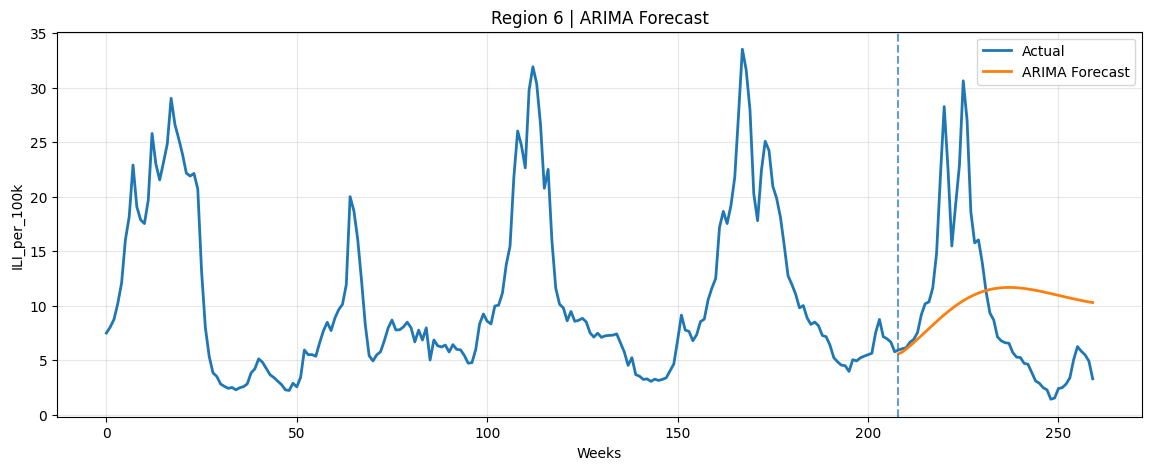

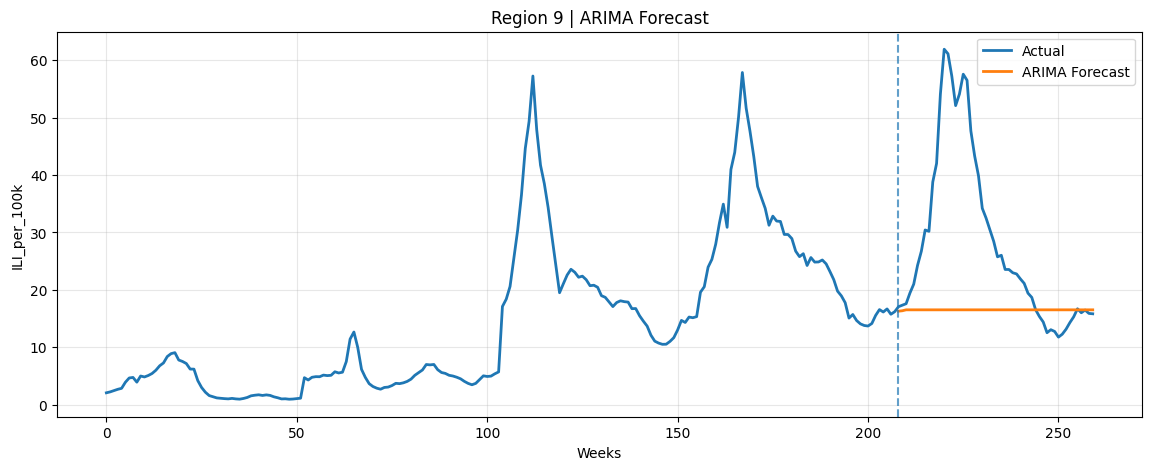

In [ ]:
plot_arima("Region 4")
plot_arima("Region 6")
plot_arima("Region 9")

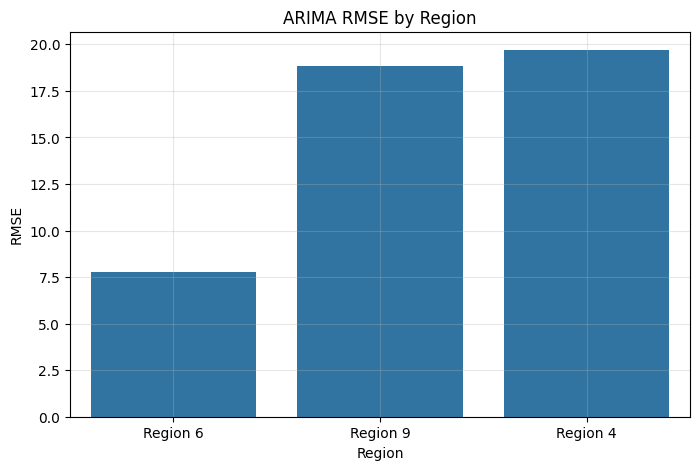

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Region",
    y="RMSE"
)

plt.title("ARIMA RMSE by Region")
plt.grid(True, alpha=0.3)
plt.show()